In [22]:
pip install requests beautifulsoup4 tqdm

Note: you may need to restart the kernel to use updated packages.


# getting script links 

In [24]:
import requests
from bs4 import BeautifulSoup
#adding url scripts data base
BASE_URL="https://imsdb.com"
#get the main script listing page
response=requests.get(f"{BASE_URL}/all-scripts.html")
soup=BeautifulSoup(response.text, "html.parser")

#find all links to individual movie pages
script_links=[]
for link in soup.select("td a[href^='/Movie Scripts/']"):  # Movie script links
    script_links.append(BASE_URL+link["href"])
print(f"found {len(script_links)} movie scripts.")


found 1302 movie scripts.


# Downloading scripts 

In [ ]:
import os
import time
from tqdm import tqdm

#define folder path relative to the current working directory
scripts_folder=os.path.join(os.getcwd(), "MovieScripts")

#create the folder if it doesnt exist
os.makedirs(scripts_folder, exist_ok=True)
all_scripts={}

for url in tqdm(script_links): # loop through each script page
    try:
        res=requests.get(url)
        if res.status_code!=200:
            print(f"Couldn't get page: {url}")
            continue

        soup=BeautifulSoup(res.text, "html.parser")

        #try to find the link to the actual script
        script_subpage=None
        for a in soup.find_all("a", href=True):
            if "scripts/" in a["href"]:
                script_subpage=BASE_URL+a["href"]
                break

        if not script_subpage:
            print(f"Didn't find script link on: {url}")
            continue

        #get the actual script page
        script_res=requests.get(script_subpage)
        if script_res.status_code != 200:
            print(f"Failed to load script from {script_subpage}")
            continue

        script_soup=BeautifulSoup(script_res.text, "html.parser")
        script_tag=script_soup.find("pre")

        if script_tag:
            text=script_tag.get_text()
            title=url.split("/")[-1].replace(" Script.html", "").replace(" ", "_")

            with open(os.path.join(scripts_folder, f"{title}.txt"), "w", encoding="utf-8") as f:
                f.write(text)

            all_scripts[title]=text
            print(f"Saved: {title}.txt")
        else:
            print(f"No script content found at {script_subpage}")

        time.sleep(1)  

    except Exception as e:
        print(f"Something went wrong with {url}: {e}")

  0%|                                                  | 0/1302 [00:00<?, ?it/s]

Saved: Predator.txt


  0%|                                        | 1/1302 [00:03<1:21:23,  3.75s/it]

Saved: Master_and_Commander.txt


  0%|                                          | 2/1302 [00:05<53:07,  2.45s/it]

...

  3%|█▏                                       | 36/1302 [01:01<34:10,  1.62s/it]

Saved: A_Scanner_Darkly.txt


  3%|█▏                                       | 37/1302 [01:02<34:12,  1.62s/it]

Saved: A_Serious_Man.txt


  3%|█▏                                       | 39/1302 [01:04<25:20,  1.20s/it]

 # detecting cliches

In [51]:
import re
import csv

#path to folder
folder_path='MovieScripts'

#defining the cliches
cliches={"red wire or blue wire cliche: Red or Blue Wire": r"(?i)\b(red wire|blue wire|red or blue|blue or red)\b(?:\s+\w+){0,6}?\s+\b(cut|which|do i cut|should i cut|was it|is it|choose|pick|decide|go with|snip)\b|\b(cut|snip|choose|pick)\b(?:\s+\w+){0,6}?\s+\b(red wire|blue wire|red or blue|blue or red)\b",
         "go on without me cliche": r"(?i)\b(go on without me|leave me behind|save yourself|i'?ll hold them off|i'?ll stay behind|i can buy (you|us|them) time|get (them|you|us) out)\b",
         "lone wolf cliche": r"(?i)\b(I|we|they)\b(?:\s+\w+){0,5}?\s+\b(work|operate|fight|do)\b(?:\s+\w+){0,5}?\s+\b(alone|by myself|on my own|solo|independently|without help|without anyone)\b",
         "you're going to want to see this": r"(?i)\b(you( are|’re|re)?|you guys)\b(?:\s+\w+){0,6}?\s+\b(gonna|going to|wanna)\b(?:\s+\w+){0,3}?\s+\b(see|look at|check (this|it) out|take a look|come (see|here))\b",
         "fake out death": r"(?i)\b(i|we|they|everyone)\b(?:\s+\w+){0,4}?\s+\bthought\b(?:\s+\w+){0,4}?\s+\b(you|he|she)\b(?:\s+\w+){0,3}?\s+\b(was|were)\b(?:\s+\w+){0,2}?\s+\b(dead|gone|lost)\b",
         "love triangle": r"(?i)\b(I|he|she|they)\b(?:\s+\w+){0,5}?\s+\b(love|have feelings for|am in love with|fell for|am falling for|can’t choose between)\b(?:\s+\w+){0,5}?\s+\b(him and you|her and you|two people|both of you|you both|them both|the two of you|more than one person|someone else|another guy|another girl|the other (man|woman|person))\b",
         "grand gesture": r"(?i)\b(I|he|she|they)\b(?:\s+\w+){0,5}?\s+\b(had to|needed to|wanted to|came here to|couldn't let you go without|couldn’t leave without|ran through the airport to|stood in the rain to|just had to)\b(?:\s+\w+){0,5}?\s+\b(tell you|show you|say this|do this|prove it|make it right)\b(?:\s+\w+){0,5}?\s+\b(I love you|I'm sorry|take me back|please stay|marry me|I was wrong|I can’t lose you|don’t go)\b",
         "change of heart": r"(?i)\b(I|he|she|they)\b(?:\s+\w+){0,5}?\s+\b(realize|realizes|realized|changed (my|his|her|their) mind|came to understand)\b(?:\s+\w+){0,5}?\s+\b(love|feelings|care|how much you mean|what I’ve been missing|this is right)\b",
         "happy ending": r"(?i)\b(happily ever after|happy ending|perfect ending|finally together|we made it|end of the road|we’re meant to be)\b(?:\s+\w+){0,3}?\s+\b(together|forever|happily ever after)\b",
         "creepy basement": r"(?i)\b(basement|cellar|downstairs|underground)\b(?:\s+\w+){0,5}?\s+\b(creepy|dark|strange|weird|cold|smells|something’s down there|don’t go|what was that|I heard (something|a noise)|it’s too quiet|I don’t like it|why is it open|it’s unlocked|it’s moving|I’m not going down there|do we have to)\b|\b(i’m not|we’re not|let’s not)\b(?:\s+\w+){0,5}?\s+\b(go(ing)? down|check it out|look in|open it)\b(?:\s+\w+){0,5}?\s+\b(basement|cellar|downstairs)\b",
         "argument about splitting up": r"(?i)(let( s)?|should we|maybe we should|how about we|why don’t we)\b(?:\s+\w+){0,5}?\s+\b(split up|go (our|different) ways|search separately|go alone|separate|divide up)\b(?:\s+\w+){0,5}?\s+\b(\?|\.|!|$)",
         "summoning ritual": r"(?i)\b(ritual|chant|incantation|ceremony|circle|symbol|sigil|sacrifice|book|relic|artifact)\b(?:\s+\w+){0,5}?\s+\b(to|and)\b(?:\s+\w+){0,5}?\s+\b(summon|awaken|unleash|resurrect)\b(?:\s+\w+){0,5}?\s+\b(demon|spirit|entity|ghost|creature|evil|presence|monster|supernatural|darkness)\b",
         "happily ever after": r"\b(and they all lived happily ever after)\b",
         "the chosen one trope": r"(?i)\b(I|you|he|she|they)\b(?:\s+\w+){0,5}?\b(chosen one|destined|fated|the one|selected|elected)\b(?:\s+\w+){0,5}?\b(for|to|as|to be)\b(?:\s+\w+){0,5}?\b(savior|hero|chosen one|destiny|role|task|purpose|prophecy|greatness|mission)\b",
         "i think we've got company": r"\b(we|i)(?:\s+\w+){0,2}?\s+(got|have)(?:\s+\w+){0,2}?\s+company\b|\blooks(?:\s+\w+){0,2}?\s+like(?:\s+\w+){0,2}?\s+(we\s+)?(got|have)?(?:\s+\w+){0,2}?\s+company\b|\bincoming\b"}

# Finding the cliches in the scripts
def find_cliches_in_scripts(folder_path, cliches):
    # Dictionary to store matches by cliché name
    cliche_matches={cliche_name: [] for cliche_name in cliches}
    
    # Getting all files in the folder
    all_files=[filename for filename in os.listdir(folder_path) if filename.endswith('.txt')]
    if not all_files:
        print("No .txt files found in the directory.")
        return cliche_matches

    print(f"Found {len(all_files)} script files.")
    
    #use tqdm for a progress bar while processing files as it was taking a while so i wanted to check if it was working 
    for filename in tqdm(all_files, desc="Processing Scripts", unit="file"):
        with open(os.path.join(folder_path, filename), 'r', encoding='utf-8') as file:
            script_text=file.read()

        #flag to check if there are any matches
        matched=False
        #search for each cliche in the script
        for cliche_name, cliche_regex in cliches.items():
            matches=re.findall(cliche_regex, script_text)
            if matches:  # If there are matches for the cliche
                cliche_matches[cliche_name].append((filename, len(matches)))
                matched=True
        #ifno matches were found, add a row with 0 matches
        if not matched:
            for cliche_name in cliches:
                cliche_matches[cliche_name].append((filename, 0))
    return cliche_matches
cliche_results=find_cliches_in_scripts(folder_path, cliches)
#saving results to cliches.csv
with open('cliches.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer=csv.writer(csvfile)
    writer.writerow(['cliché', 'title', 'match count'])  # Writing header row
    for cliche_name, matches in cliche_results.items():
        for filename, count in matches:
            writer.writerow([cliche_name, filename, count])

print("Results have been saved to 'cliches.csv'.")


Found 1220 script files.


Processing Scripts: 100%|█████████████████| 1220/1220 [03:57<00:00,  5.13file/s]

Results have been saved to 'cliches.csv'.


# cleaning cliches.csv

In [64]:
# loading the cliches.csv file
df=pd.read_csv('cliches.csv')
# replacing underscores with spaces in the title column
df['title']=df['title'].str.replace('_', ' ')
# removing .txt
df['title']=df['title'].str.replace('.txt', '', regex=False)
# changing the format of film names with 'the'
df['title']=df['title'].apply(lambda x: 'The ' + x.split(',')[0] if ', The' in x else x)
# deleting the 'cliché' column
df=df.drop(columns=['cliché'])
# renaming 'Match Count' column to 'cliché'
df=df.rename(columns={'match count': 'cliché'})
# saving changes to a CSV
df.to_csv('cliches_cleaned.csv', index=False)
# printing the first few rows to verify the changes
print(df.head())




           title  cliché
0  The Brutalist       0
1        Warrior       0
2   May December       0
3     Angel Eyes       0
4       Bad Boys       0


# joining with success_metrics.csv to create cliches_success.csv

In [70]:
import pandas as pd
cliches_cleaned_df=pd.read_csv('cliches_cleaned.csv')
success_metrics_df=pd.read_csv('success_metrics.csv')

# inner join on the 'title' column
merged_df=pd.merge(cliches_cleaned_df, success_metrics_df, on='title', how='inner')

#renaming the 'matches' column to 'cliche matches'
merged_df=merged_df.rename(columns={'matches': 'cliche matches'})

#saving it to new csv file
merged_df.to_csv('cliches_success.csv', index=False)

In [72]:
df=pd.read_csv('cliches_success.csv')

#ensuring duplicates are dropped 
df=df.drop_duplicates(subset=['title', 'awards_all'], keep='first')
# Save the cleaned dataframe back to the CSV
df.to_csv('cliches_success.csv', index=False)

In [76]:
#checking i have enough cliched movies to do analysis
non_zero_cliches_count=(df['cliché'] != 0).sum()
# printing the result
print(f"{non_zero_cliches_count}")


315


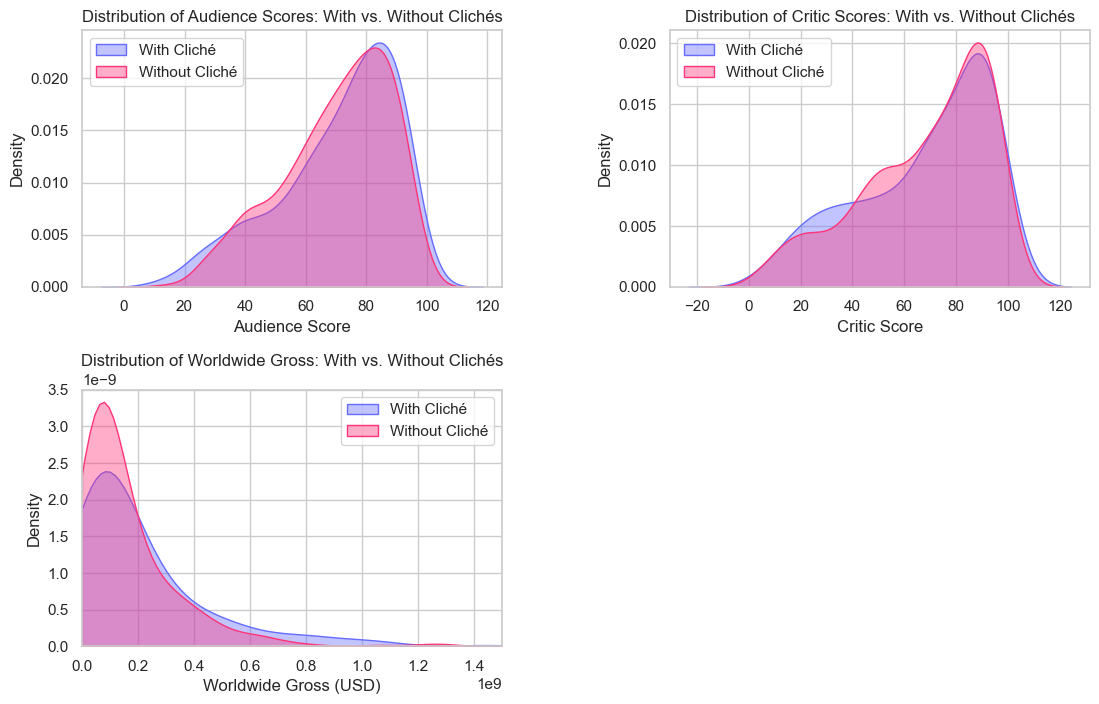

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('cliches_success.csv')
#creating the plot (doing 4 as otherwise it doesnt work)
fig, axes=plt.subplots(2, 2, figsize=(13, 8))

#critic ratings plot
sns.kdeplot(data=df[df['cliché']>0], x='audience_score', label='With Cliché', fill=True, alpha=0.4, color="#656CFE", ax=axes[0, 0])
sns.kdeplot(data=df[df['cliché']==0], x='audience_score', label='Without Cliché', fill=True, color='#FF3377', alpha=0.4, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Audience Scores: With vs. Without Clichés')
axes[0, 0].set_xlabel('Audience Score')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

#critic ratings plot
sns.kdeplot(data=df[df['cliché']>0], x='critic_score', label='With Cliché', fill=True, color="#656CFE" ,alpha=0.4, ax=axes[0, 1])
sns.kdeplot(data=df[df['cliché']==0], x='critic_score', label='Without Cliché', color='#FF3377',fill=True, alpha=0.4, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Critic Scores: With vs. Without Clichés')
axes[0, 1].set_xlabel('Critic Score')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

#box office plot
sns.kdeplot(data=df[df['cliché'] > 0], x='worldwide_gross', label='With Cliché', fill=True, alpha=0.4, color="#656CFE", ax=axes[1, 0])
sns.kdeplot(data=df[df['cliché']==0], x='worldwide_gross', label='Without Cliché', color='#FF3377',fill=True, alpha=0.4, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Worldwide Gross: With vs. Without Clichés')
axes[1, 0].set_xlabel('Worldwide Gross (USD)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].set_xlim(0, 1.5e9)  #cropping the box office plot at 1.5 billion as there isnt much data after that point

#remove unecessary subplot 
fig.delaxes(axes[1, 1])

fig.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()

In [147]:
df = pd.read_csv('cliches_success.csv')
averages=df.groupby(df['cliché'].apply(lambda x:'With Cliché' if x>0 else 'Without Cliché'))[['audience_score', 'critic_score', 'worldwide_gross']].mean()
#priting 
print(averages)


                audience_score  critic_score  worldwide_gross
cliché                                                       
With Cliché          70.600000     67.495238     2.241982e+08
Without Cliché       69.991091     67.881960     1.691315e+08
